# TrendLens — 01 · Dataset Exploration (Phase 1)

**Goal:** inspect the SMPD download, produce a clear dataset report, and build the deterministic 5,000-image sample that every later stage will reuse.

> **DATA INTEGRITY NOTICE:** only the image files and the path index are real. Engagement metadata (likes, comments, timestamps, tags, geo) is **synthetic demo data** and is flagged as such throughout. Nothing derived from it is a research finding.

## 0 · Environment

On Colab, the project lives in the repo root (clone it or mount Drive and run from the repo). Everything imports `config` from the repo root, so add that directory to `sys.path` if needed.

In [1]:
import sys
from pathlib import Path

REPO = Path.cwd()
if not (REPO / "config.py").exists():
    for p in Path.cwd().parents:
        if (p / "config.py").exists():
            REPO = p
            break
sys.path.insert(0, str(REPO))

import config
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
print("repo:", REPO)

repo: /home/akriti/Documents/Project/trendlens


## 1 · Load data & apply the schema mapping

Column names are read from `config.DATASET_CONFIG`, never hard-coded.

In [2]:
from src import data_loader as dl

raw = dl.load_metadata()
print("raw columns:", list(raw.columns))
df = dl.apply_dataset_config(raw, config.DATASET_CONFIG)
df.head()

raw columns: ['post_id', 'user_id', 'photo_id', 'photo_id_int', 'image_path', 'timestamp', 'likes', 'comments', 'reposts', 'saves', 'views', 'reach', 'follower_count', 'engagement_rate', 'is_viral', 'category', 'tags', 'groups', 'geo_lat', 'geo_lon', 'geo_city', 'user_total_posts', 'is_synthetic', 'trend_duration_days', 'trend_active_until']


,post_id,user_id,photo_id,photo_id_int,image_path,timestamp,likes,comments,reposts,saves,...,tags,groups,geo_lat,geo_lon,geo_city,user_total_posts,is_synthetic,trend_duration_days,trend_active_until,caption
0,59@N75_775,59@N75,775,775,train/59@N75/775.jpg,2016-09-22 16:26:48+00:00,76,3,0,0,...,"[""creative"", ""abstract"", ""pattern"", ""instagram...","[""Urban Landscapes"", ""Architecture Daily"", ""Wo...",-33.851471,18.564353,Cape Town,3,True,16.552827,2016-10-09T05:42:52Z,NaN
1,1@N18_1075,1@N18,1075,1075,train/1@N18/1075.jpg,2014-04-13 00:42:08+00:00,136,14,1,1,...,"[""vacation"", ""wanderlust""]","[""Best of Flickr"", ""Documentary Photography"", ...",NaN,NaN,NaN,7,True,8.501169,2014-04-21T12:43:49Z,NaN
2,351@N64_4890,351@N64,4890,4890,train/351@N64/4890.jpg,2010-03-03 21:28:32+00:00,11,0,0,0,...,"[""scenic"", ""nature"", ""moment"", ""photo""]","[""Architecture Daily"", ""Explore""]",NaN,NaN,NaN,1,True,11.042112,2010-03-14T22:29:10Z,NaN
3,6@N59_6568,6@N59,6568,6568,train/6@N59/6568.jpg,2013-03-24 12:40:14+00:00,90,2,0,2,...,"[""face"", ""portrait"", ""model"", ""selfie"", ""peopl...","[""Street Shots"", ""Color Explosion"", ""Black & W...",13.743033,100.412509,Bangkok,1,True,9.550057,2013-04-03T01:52:18Z,NaN
4,1617@N40_7079,1617@N40,7079,7079,train/1617@N40/7079.jpg,2014-01-26 18:34:36+00:00,26,0,0,0,...,"[""party"", ""club"", ""nightlife"", ""snapshot"", ""ca...","[""Architecture Daily""]",48.851291,2.437021,Paris,26,True,1.948952,2014-01-28T17:21:05Z,NaN


## 2 · Dataset report

Posts / users / images, date range, missing values, caption & timestamp coverage, engagement statistics, sampled image dimensions and a posts-over-time distribution.

In [3]:
stats = dl.dataset_report(df, sample=8)
stats

TRENDLENS — DATASET REPORT
Posts              : 69,226
Unique images      : 69,226
Unique users       : 5,574
Timestamp coverage : 100.0%
Date range         : 2010-01-01T00:00:00+00:00 → 2019-12-31T00:00:00+00:00

Missing-value rate (nonzero):
  caption                      100.0%
  geo_lon                      30.0%
  geo_city                     30.0%
  geo_lat                      30.0%

Caption coverage   : 0.0%  (caption_column in DATASET_CONFIG is None/absent)

Engagement (likes+comments):
  mean   : 77.5
  median : 44.0
  p90    : 174.0
  max    : 3974.0

Sampled image dimensions:
  train/23798@N69/277121.jpg  (500, 333)
  train/22646@N78/161575.jpg  (500, 429)
  train/26037@N82/179142.jpg  (500, 333)
  train/25403@N89/402366.jpg  (500, 333)
  train/16988@N76/238965.jpg  (334, 500)
  train/21950@N83/207249.jpg  (475, 500)
  train/24607@N38/162952.jpg  (500, 375)
  train/13549@N68/186445.jpg  (500, 375)

Posts per year:
  2010  9,225
  2011  7,239
  2012  7,971
  2013  8,284
  20

{'n_posts': 69226,
 'n_images': 69226,
 'n_users': 5574,
 'synthetic_metadata': True,
 'timestamp_coverage': 1.0,
 'date_min': '2010-01-01T00:00:00+00:00',
 'date_max': '2019-12-31T00:00:00+00:00',
 'caption_coverage': 0.0,
 'engagement': {'mean': 77.52995984167798,
  'median': 44.0,
  'max': 3974.0,
  'p90': 174.0},
 'image_dimensions': {'train/23798@N69/277121.jpg': (500, 333),
  'train/22646@N78/161575.jpg': (500, 429),
  'train/26037@N82/179142.jpg': (500, 333),
  'train/25403@N89/402366.jpg': (500, 333),
  'train/16988@N76/238965.jpg': (334, 500),
  'train/21950@N83/207249.jpg': (475, 500),
  'train/24607@N38/162952.jpg': (500, 375),
  'train/13549@N68/186445.jpg': (500, 375)},
 'posts_per_year': {'2010': 9225,
  '2011': 7239,
  '2012': 7971,
  '2013': 8284,
  '2014': 8784,
  '2015': 8959,
  '2016': 8222,
  '2017': 5909,
  '2018': 3139,
  '2019': 1494},
 'posts_per_month': {'2010-01': 4285,
  '2010-02': 298,
  '2010-03': 391,
  '2010-04': 381,
  '2010-05': 451,
  '2010-06': 447,
 

## 3 · Plots

Posts per month/year, engagement distribution, caption length and missing data.

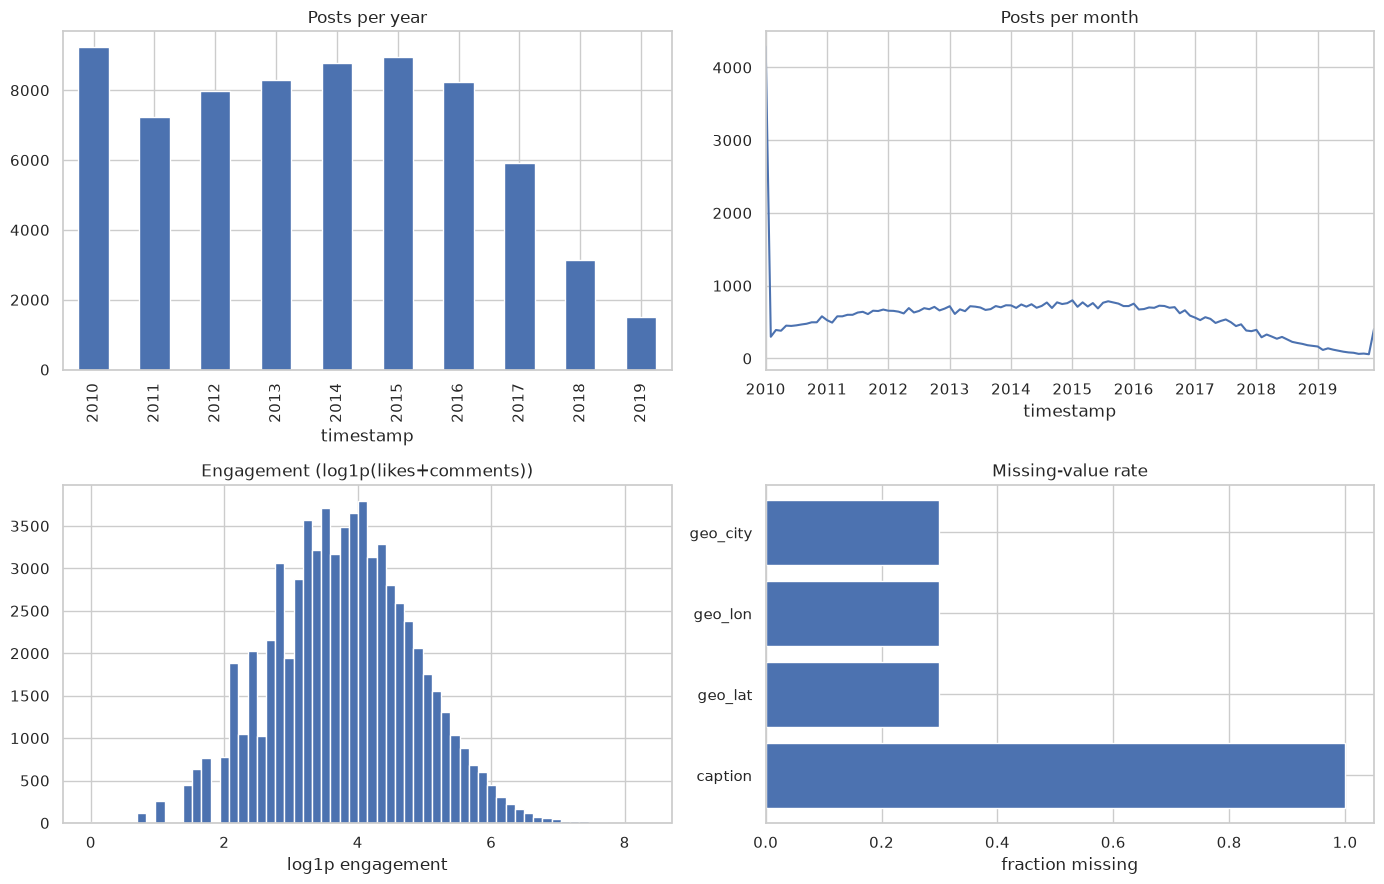

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

t = df["timestamp"].dropna()
t_naive = t.dt.tz_localize(None) if t.dt.tz is not None else t

# posts per year
t.dt.year.value_counts().sort_index().plot(kind="bar", ax=axes[0, 0], title="Posts per year")

# posts per month
t_naive.dt.to_period("M").value_counts().sort_index().plot(ax=axes[0, 1], title="Posts per month")

# engagement distribution
eng = df["likes"].fillna(0) + df["comments"].fillna(0)
axes[1, 0].hist(np.log1p(eng), bins=60)
axes[1, 0].set_title("Engagement (log1p(likes+comments))")
axes[1, 0].set_xlabel("log1p engagement")

# missing data
missing = df.isna().mean()
missing = missing[missing > 0].sort_values(ascending=False)
axes[1, 1].barh(missing.index, missing.values)
axes[1, 1].set_title("Missing-value rate")
axes[1, 1].set_xlabel("fraction missing")

plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "01_dataset_exploration.png", dpi=150, bbox_inches="tight")
plt.show()

**Caption length:** the local SMPD files have no caption column (`caption_column=None` in `DATASET_CONFIG`), so caption length is not computable — reported as 0% coverage above. This matters for the text baseline in Phase 4: we will need tags/keywords instead.

## 4 · Sample images

A deterministic sample of a few images with their paths and engagement.

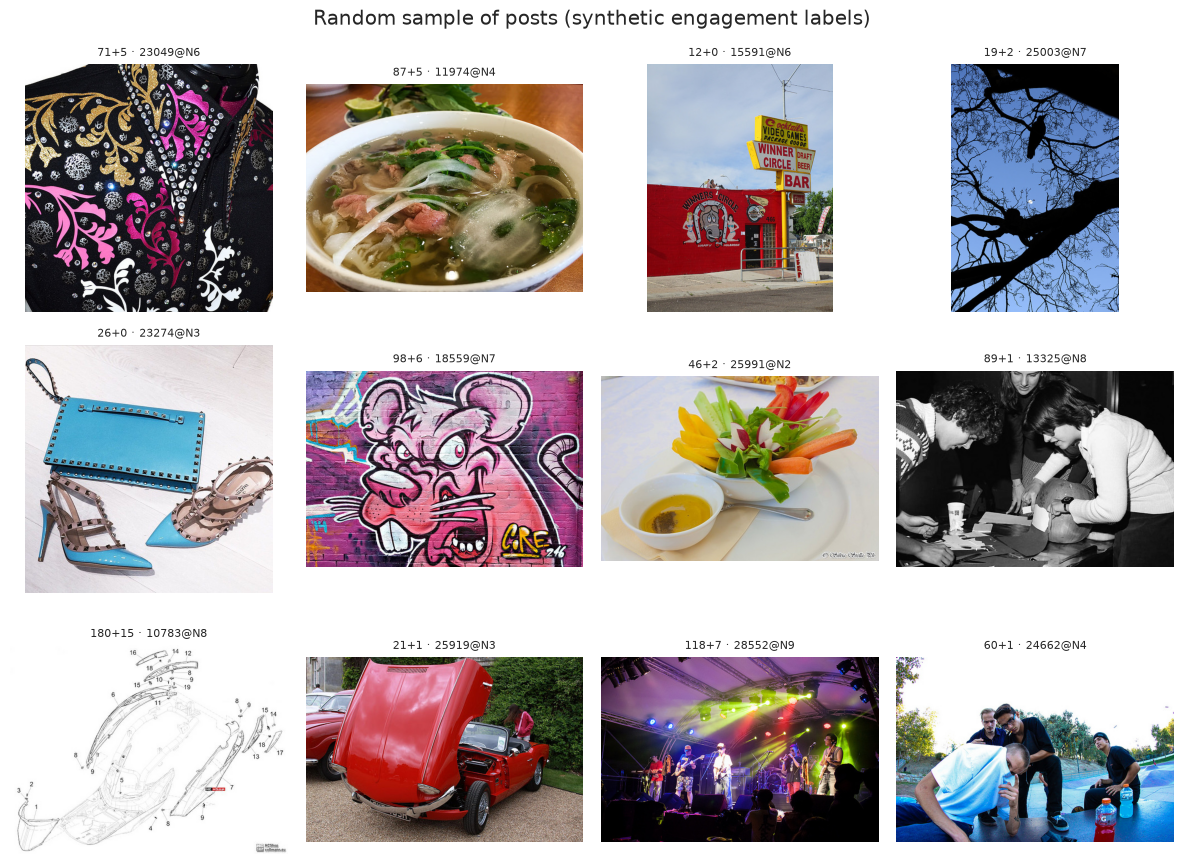

In [5]:
from src import preprocessing as pp
from PIL import Image

sample = dl.sample_posts(df, n=12, seed=1, by_user=False)
fig, axes = plt.subplots(3, 4, figsize=(12, 9))
for ax, row in zip(axes.flat, sample.itertuples()):
    try:
        img = pp.load_image(row.image_path)
        ax.imshow(img)
    except Exception:
        ax.text(0.5, 0.5, "load failed", ha="center", va="center")
    ax.set_title(f"{row.likes}+{row.comments} · {row.user_id[:8]}", fontsize=8)
    ax.axis("off")
plt.suptitle("Random sample of posts (synthetic engagement labels)")
plt.tight_layout()
plt.show()

## 5 · Build the reusable 5,000-image subset

Deterministic round-robin sample (one post per user first) so the subset is stable, user-diverse, and every later stage reuses the same manifest. The parquet row order **is** the embedding order in Phase 2.

In [6]:
subset = dl.sample_posts(df, n=config.N_IMAGES, seed=config.RANDOM_SEED)
manifest = dl.save_sample_manifest(subset)
print("subset rows:", len(subset))
print("unique users:", subset["user_id"].nunique())
print("manifest:", manifest)
subset[["post_id", "user_id", "image_path", "timestamp", "likes", "comments"]].head()

subset rows: 5000
unique users: 5000
manifest: /home/akriti/Documents/Project/trendlens/data/processed/sample_metadata.parquet


,post_id,user_id,image_path,timestamp,likes,comments
0,22350@N26_146974,22350@N26,train/22350@N26/146974.jpg,2013-01-04 06:56:59+00:00,82,4
1,26213@N93_173608,26213@N93,train/26213@N93/173608.jpg,2014-05-20 02:47:11+00:00,268,14
2,22348@N48_149856,22348@N48,train/22348@N48/149856.jpg,2016-02-28 18:54:09+00:00,192,15
3,27483@N48_183561,27483@N48,train/27483@N48/183561.jpg,2016-11-17 11:43:08+00:00,12,0
4,25943@N57_175188,25943@N57,train/25943@N57/175188.jpg,2011-09-20 19:30:32+00:00,41,1


## 6 · Validate the subset images

Robust validation (corrupt/missing handling) over the 5,000 selected files. Results are cached to `data/processed/validated_images.json`.

In [7]:
loader = pp.ImageBatchLoader(
    subset["image_path"],
    batch_size=128,
    cache_validated=True,
    show_progress=True,
)
n_valid = sum(1 for _ in loader.iter_images())
print(f"valid images: {n_valid} / {len(subset)}")
print("bad files:", dict(list(loader.bad.items())[:5]))
print("total bad:", len(loader.bad))

Loading images:   0%|          | 0/5000 [00:00<?, ?it/s]

valid images: 5000 / 5000
bad files: {}
total bad: 0


## Phase 1 checkpoint

- [x] Dataset schema inspection + report
- [x] Deterministic 5,000-image sampling pipeline (manifest saved)
- [x] Robust image validation over the subset

**Next (Phase 2):** CLIP embeddings on this exact subset, batch + checkpoint + resume.